In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
maxSteps = 20000

<Figure size 640x480 with 0 Axes>

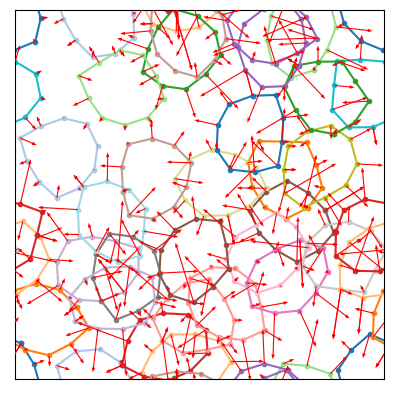

In [3]:
numPolygons = 32
n = 10
nVals = [0, 1, 2, 3, 9, 4 ,5, 6, 20, 25, 35, 54]
i = 5
phi = 1.0
kappa = 3.7
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")

m.generateRandomPolygons(numPolygons, n, kappa = kappa, phi = phi)
#modelDir = "playersTesting/" + str(np.max(np.array(os.listdir("playersTesting")).astype(int)))
#m.loadModel(modelDir)
plt.clf()

m.setStiffness(1)
m.setMaxEdgeLength()

m.setPositions(m.getPositions() + np.random.randn(m.getNumVertices() * 2) * 0.001)
#m.loadModel("parallel")
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
m.updateConstraintForces()
force0 = m.getConstraintForces()
positions0 = m.getPositions()# Now you have dA, can you draw arrows on the vertices?
artists = m.draw(forces = force0, arrowColor = 'r')

In [ ]:
m.minimizeGD(dt = 1e-4, maxSteps = maxSteps, progressBar = True)

Processing:  92%|██████████████████████  | 18436/20000 [00:52<00:04, 339.36it/s]

In [ ]:
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
m.updateConstraintForces()
force0 = m.getConstraintForces()
positions0 = m.getPositions()# Now you have dA, can you draw arrows on the vertices?
artists = m.draw(forces = force0, arrowColor = 'r')

In [ ]:
print(m.getEnergy())

In [ ]:
m.getMaxUnbalancedForce()

In [ ]:
np.mean(m.getAreas()), np.std(m.getAreas())

In [ ]:
m.saveModel("progress", overwrite = True)

In [ ]:
0.7147665882227807